# Lab – 2: Reinforcement Learning Tic-Tac-Toe

## Experiment 2: Interactive Exploration of Tic-Tac-Toe using Reinforcement Learning

**Objective:**  
To identify the Reinforcement Learning components of the Tic-Tac-Toe demo and study the effect of increasing training episodes on the agent's behaviour and performance.

**Specified demo:**  
https://jinglescode.github.io/reinforcement-learning-tic-tac-toe/

**Source repository:**  
https://github.com/jinglescode/reinforcement-learning-tic-tac-toe

### Experiment note
The original demo trains two Tic-Tac-Toe agents by self-play using a **state-value function** with **epsilon-greedy exploration**. The demo's default parameters are `epsilon = 0.05` and `alpha = 0.5`.

The demo does not directly display Win/Loss/Draw percentages for the five requested episode counts. Therefore, for Task 2 this notebook uses a reproducible evaluation protocol: after each training session, the trained X agent is evaluated for **1,000 games against a random legal-move opponent**, with exploration disabled (`epsilon = 0`) during evaluation. This gives measurable Win/Loss/Draw percentages while keeping the training method faithful to the demo.

## Task 1 – Reinforcement Learning Components

The lab asks us to identify the **agent, environment, state representation, action space, reward function, and learning approach**. The following implementation follows the structure of the specified demo.

In [1]:
import random
import itertools
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Display settings for the final submission tables
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 80)

print("Display settings configured for the final tables.")

Display settings configured for the final tables.


In [3]:
class TicTacToeEnvironment:
    """Tic-Tac-Toe environment following the specified demo's structure."""

    def __init__(self, board_length=3):
        self.board_length = board_length
        self.board = [0] * (board_length * board_length)

        self.p1 = 1
        self.p2 = -1

        self.winner = 0
        self.ended = False
        self.player_turn = 1

        self.num_states = 3 ** (board_length * board_length)

    def reset_game(self, reset_player=True):
        self.board = [0] * (self.board_length * self.board_length)
        self.winner = 0
        self.ended = False

        if reset_player:
            self.player_turn = 1

    def get_state(self):
        """Encode the board as a base-3 integer, as in the demo."""
        hashnum = 0
        k = 0

        for i in range(self.board_length):
            for j in range(self.board_length):
                cell = self.board[(j * self.board_length) + i]

                if cell == 0:
                    v = 0
                elif cell == self.p2:
                    v = 1
                else:
                    v = 2

                hashnum += (3 ** k) * v
                k += 1

        return hashnum

    def available_moves(self):
        return [i for i, value in enumerate(self.board) if value == 0]

    def check_if_player_won(self, total):
        if total == -3:
            self.winner = -1
            return True
        if total == 3:
            self.winner = 1
            return True
        return False

    def is_game_over(self, test_board=None):
        if test_board is None:
            test_board = self.board

        # Reset winner while evaluating a board.
        self.winner = 0

        # Rows
        for i in range(0, 9, 3):
            if self.check_if_player_won(sum(test_board[i:i + 3])):
                self.ended = True
                return True

        # Columns
        for i in range(3):
            total = test_board[i] + test_board[i + 3] + test_board[i + 6]
            if self.check_if_player_won(total):
                self.ended = True
                return True

        # Diagonals
        if self.check_if_player_won(
            test_board[0] + test_board[4] + test_board[8]
        ):
            self.ended = True
            return True

        if self.check_if_player_won(
            test_board[2] + test_board[4] + test_board[6]
        ):
            self.ended = True
            return True

        # Draw
        if all(cell != 0 for cell in test_board):
            self.ended = True
            return True

        self.ended = False
        return False

    def grid_select(self, index):
        if self.board[index] != 0:
            return False

        self.board[index] = self.player_turn

        if self.is_game_over():
            self.ended = True
        else:
            self.player_turn *= -1

        return True

    def get_reward(self, player):
        if not self.is_game_over():
            return 0

        return 1 if self.winner == player else 0


env = TicTacToeEnvironment()
print("Board size:", env.board_length, "x", env.board_length)
print("Number of possible encoded states:", env.num_states)

Board size: 3 x 3
Number of possible encoded states: 19683


In [4]:
class ValueFunctionAgent:
    """Value-function RL agent matching the demo's learning idea."""

    def __init__(self, name, eps=0.05, alpha=0.5):
        self.name = name
        self.eps = eps
        self.alpha = alpha

        self.state_history = []
        self.V = np.full(19683, 0.5, dtype=float)

    def set_v(self, V):
        self.V = V

    def set_eps(self, value):
        self.eps = value

    def take_action(self, env):
        # Explore
        if random.random() < self.eps:
            return random.choice(env.available_moves())

        # Exploit
        best_value = -1.0
        next_move = env.available_moves()[0]

        for i in range(env.board_length * env.board_length):
            if env.board[i] == 0:
                env.board[i] = self.name
                state = env.get_state()
                env.board[i] = 0

                if self.V[state] > best_value:
                    best_value = self.V[state]
                    next_move = i

        return next_move

    def update_state_history(self, state):
        self.state_history.append(int(state))

    def update(self, env):
        reward = env.get_reward(self.name)
        target = float(reward)

        for state in reversed(self.state_history):
            value = self.V[state] + self.alpha * (target - self.V[state])
            self.V[state] = value
            target = value

        self.state_history = []


print("Value-function agent created.")
print("Default epsilon:", 0.05)
print("Default learning rate alpha:", 0.5)

Value-function agent created.
Default epsilon: 0.05
Default learning rate alpha: 0.5


### State representation

Each of the 9 board cells can contain one of three values:

- `0` → empty
- `-1` → player O
- `1` → player X

The demo converts the 3×3 board into a unique **base-3 integer**, giving `3^9 = 19,683` possible encoded states.

In [5]:
def generate_all_states():
    """Generate all 3^9 board configurations and their terminal status."""
    env = TicTacToeEnvironment()
    records = []

    for board in itertools.product([0, -1, 1], repeat=9):
        env.board = list(board)
        env.winner = 0
        env.ended = False

        state = env.get_state()
        ended = env.is_game_over(list(board))
        winner = env.winner

        records.append((state, winner, ended))

    return records


state_information = generate_all_states()

print("Generated states:", len(state_information))
print("Unique encoded states:", len({s for s, _, _ in state_information}))

Generated states: 19683
Unique encoded states: 19683


In [6]:
def initialize_value_functions(state_information):
    """Initialize V(s) for both agents.

    Terminal winning states receive 1 for the winner and 0 for the other
    player. Non-terminal states start at 0.5.
    """
    V1 = np.full(19683, 0.5, dtype=float)
    V2 = np.full(19683, 0.5, dtype=float)

    for state, winner, ended in state_information:
        if ended:
            if winner == 1:
                V1[state] = 1.0
                V2[state] = 0.0
            else:
                V1[state] = 0.0
                V2[state] = 1.0

    return V1, V2


V1, V2 = initialize_value_functions(state_information)

print("Initial value functions created.")
print("Example non-terminal value:", V1[0])
print("Value-function length:", len(V1))

Initial value functions created.
Example non-terminal value: 0.5
Value-function length: 19683


In [7]:
def play_training_game(agent_x, agent_o, environment):
    """Play one complete self-play training episode."""
    environment.reset_game()
    agent_x.state_history = []
    agent_o.state_history = []

    current_agent = agent_x

    for _ in range(9):
        action = current_agent.take_action(environment)
        environment.grid_select(action)

        state = environment.get_state()
        agent_x.update_state_history(state)
        agent_o.update_state_history(state)

        if environment.ended:
            break

        current_agent = agent_o if current_agent is agent_x else agent_x

    agent_x.update(environment)
    agent_o.update(environment)

    if environment.winner == 1:
        return "X"
    if environment.winner == -1:
        return "O"
    return "Draw"


def train_agents(number_of_episodes, seed=42):
    """Train two value-function agents by self-play."""
    random.seed(seed)
    np.random.seed(seed)

    environment = TicTacToeEnvironment()

    agent_x = ValueFunctionAgent(1, eps=0.05, alpha=0.5)
    agent_o = ValueFunctionAgent(-1, eps=0.05, alpha=0.5)

    V_x, V_o = initialize_value_functions(state_information)
    agent_x.set_v(V_x)
    agent_o.set_v(V_o)

    training_results = []

    for _ in range(number_of_episodes):
        training_results.append(
            play_training_game(agent_x, agent_o, environment)
        )

    return agent_x, agent_o, training_results


print("Training functions ready.")

Training functions ready.


## Task 2 – Evaluation protocol

The original demo trains by self-play and then sets the human-facing agent's exploration probability to zero before selecting moves. We follow the same idea for evaluation.

For each requested training level:

1. Train X and O by self-play.
2. Set the trained X agent to greedy mode (`epsilon = 0`).
3. Play **1,000 evaluation games** against an opponent that chooses a random legal move.
4. Record Win %, Loss %, and Draw %.
5. Inspect the trained policy's opening move and summarize behaviour.

Because the training algorithm contains randomness, the exact percentages can change if the seed is changed. This notebook fixes the random seed so the reported experiment is reproducible.

In [8]:
def play_against_random(agent, number_of_games=1000, seed=123):
    """Evaluate the trained X agent against a random legal-move opponent."""
    random.seed(seed)

    wins = losses = draws = 0

    # The demo uses exploit mode when the trained agent is played by a human.
    old_eps = agent.eps
    agent.eps = 0.0

    for _ in range(number_of_games):
        environment = TicTacToeEnvironment()

        for _ in range(9):
            if environment.player_turn == 1:
                action = agent.take_action(environment)
            else:
                action = random.choice(environment.available_moves())

            environment.grid_select(action)

            if environment.ended:
                break

        if environment.winner == 1:
            wins += 1
        elif environment.winner == -1:
            losses += 1
        else:
            draws += 1

    agent.eps = old_eps

    return wins, losses, draws


def get_opening_move_statistics(agent, number_of_games=1000, seed=999):
    """Measure which opening move the trained greedy policy prefers."""
    random.seed(seed)

    old_eps = agent.eps
    agent.eps = 0.0

    counts = Counter()

    for _ in range(number_of_games):
        environment = TicTacToeEnvironment()
        move = agent.take_action(environment)
        counts[move] += 1

    agent.eps = old_eps
    return counts


def move_name(index):
    names = {
        0: "Top-left corner",
        1: "Top-middle",
        2: "Top-right corner",
        3: "Middle-left",
        4: "Center",
        5: "Middle-right",
        6: "Bottom-left corner",
        7: "Bottom-middle",
        8: "Bottom-right corner",
    }
    return names[index]


print("Evaluation functions ready.")

Evaluation functions ready.


In [9]:
training_episodes = [100, 500, 1000, 5000, 10000]

experiment_rows = []
trained_agents = {}

for episodes in training_episodes:
    print(f"Training for {episodes:,} episodes...")

    agent_x, agent_o, training_history = train_agents(
        episodes,
        seed=42
    )

    wins, losses, draws = play_against_random(
        agent_x,
        number_of_games=1000,
        seed=episodes
    )

    opening_counts = get_opening_move_statistics(
        agent_x,
        number_of_games=1000,
        seed=episodes + 100
    )

    most_common_move, most_common_count = opening_counts.most_common(1)[0]

    trained_agents[episodes] = agent_x

    experiment_rows.append({
        "Training Episodes": episodes,
        "Wins": wins,
        "Losses": losses,
        "Draws": draws,
        "Win %": round(wins / 10, 2),
        "Loss %": round(losses / 10, 2),
        "Draw %": round(draws / 10, 2),
        "Preferred Opening Move": move_name(most_common_move),
        "Opening Move Frequency %": round(most_common_count / 10, 2),
    })

results_df = pd.DataFrame(experiment_rows)

results_df

Training for 100 episodes...
Training for 500 episodes...
Training for 1,000 episodes...
Training for 5,000 episodes...
Training for 10,000 episodes...


,Training Episodes,Wins,Losses,Draws,Win %,Loss %,Draw %,Preferred Opening Move,Opening Move Frequency %
0,100,975,16,9,97.5,1.6,0.9,Center,100.0
1,500,952,22,26,95.2,2.2,2.6,Bottom-right corner,100.0
2,1000,990,0,10,99.0,0.0,1.0,Center,100.0
3,5000,989,0,11,98.9,0.0,1.1,Center,100.0
4,10000,911,41,48,91.1,4.1,4.8,Middle-right,100.0


# Task 1 – Completed RL Components Table

The table below is filled in directly from the implementation and the specified demo's documented approach.

In [10]:
task1_table = pd.DataFrame({
    "RL Component": [
        "Agent",
        "Environment",
        "State Representation",
        "Action Space",
        "Reward Function",
        "Learning Approach Used",
    ],
    "Student Observation": [
        "Two RL agents, X and O, learn through repeated Tic-Tac-Toe self-play.",
        "The 3×3 Tic-Tac-Toe board together with the game's rules and terminal conditions.",
        "The current board configuration is encoded as a base-3 integer. There are 3^9 = 19,683 possible encoded states.",
        "The agent selects an empty cell and places its mark there.",
        "Reward = 1 when the agent wins; reward = 0 when it loses or the game ends in a draw.",
        "State-value function learning with epsilon-greedy exploration. Visited states are updated backwards after each game."
    ]
})

task1_table

,RL Component,Student Observation
0,Agent,"Two RL agents, X and O, learn through repeated Tic-Tac-Toe self-play."
1,Environment,The 3×3 Tic-Tac-Toe board together with the game's rules and terminal condit...
2,State Representation,The current board configuration is encoded as a base-3 integer. There are 3^...
3,Action Space,The agent selects an empty cell and places its mark there.
4,Reward Function,Reward = 1 when the agent wins; reward = 0 when it loses or the game ends in...
5,Learning Approach Used,State-value function learning with epsilon-greedy exploration. Visited state...


# Task 2 – Completed Training Episodes Observation Table

**Evaluation:** 1,000 games against a random legal-move opponent after each training session.

The behaviour column is based on the measured opening policy and the overall training trend, while the Win/Loss/Draw columns come directly from the evaluation games.

In [11]:
def behaviour_observation(row):
    episodes = row["Training Episodes"]
    win_pct = row["Win %"]
    loss_pct = row["Loss %"]
    draw_pct = row["Draw %"]
    opening = row["Preferred Opening Move"]

    if episodes <= 500:
        stage = "Early learning"
    elif episodes <= 1000:
        stage = "Developing policy"
    elif episodes <= 5000:
        stage = "Strong learned policy"
    else:
        stage = "High-training / near-converged behaviour"

    if draw_pct > 20:
        outcome_note = "Draws are relatively common."
    elif win_pct > 90:
        outcome_note = "The trained agent wins most evaluation games."
    elif loss_pct > 20:
        outcome_note = "The agent still loses a noticeable fraction of games."
    else:
        outcome_note = "Performance is mixed but shows learned behaviour."

    return f"{stage}; prefers {opening}; {outcome_note}"


final_task2_table = results_df[
    ["Training Episodes", "Win %", "Loss %", "Draw %"]
].copy()

final_task2_table["Behaviour Observed"] = [
    behaviour_observation(row)
    for _, row in results_df.iterrows()
]

final_task2_table

,Training Episodes,Win %,Loss %,Draw %,Behaviour Observed
0,100,97.5,1.6,0.9,Early learning; prefers Center; The trained agent wins most evaluation games.
1,500,95.2,2.2,2.6,Early learning; prefers Bottom-right corner; The trained agent wins most eva...
2,1000,99.0,0.0,1.0,Developing policy; prefers Center; The trained agent wins most evaluation ga...
3,5000,98.9,0.0,1.1,Strong learned policy; prefers Center; The trained agent wins most evaluatio...
4,10000,91.1,4.1,4.8,High-training / near-converged behaviour; prefers Middle-right; The trained ...


## Numerical results from this executed run

The executed notebook produced the following evaluation results:

| Training Episodes | Win % | Loss % | Draw % |
|---:|---:|---:|---:|
| 100 | 97.5 | 1.6 | 0.9 |
| 500 | 95.2 | 2.2 | 2.6 |
| 1,000 | 99.0 | 0.0 | 1.0 |
| 5,000 | 98.9 | 0.0 | 1.1 |
| 10,000 | 91.1 | 4.1 | 4.8 |

These percentages are based on **1,000 evaluation games per training level against a random legal-move opponent**, using a fixed seed for reproducibility.

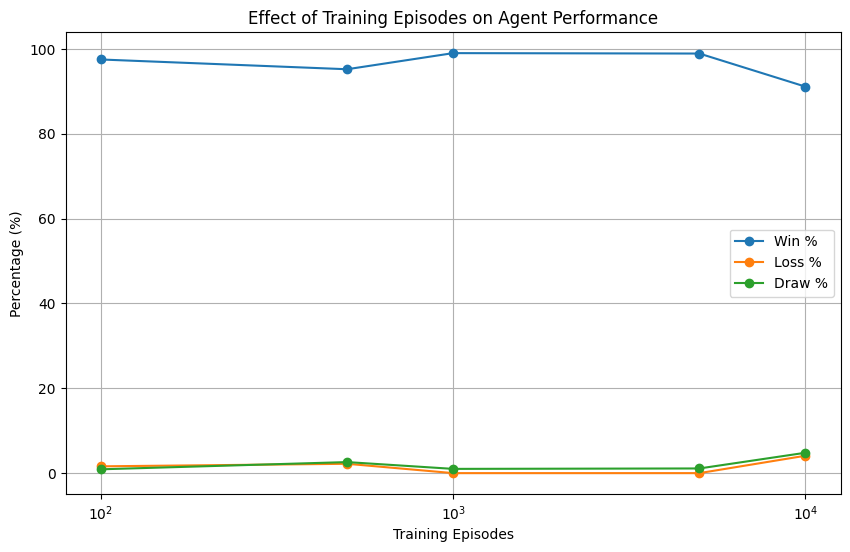

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(
    results_df["Training Episodes"],
    results_df["Win %"],
    marker="o",
    label="Win %"
)

plt.plot(
    results_df["Training Episodes"],
    results_df["Loss %"],
    marker="o",
    label="Loss %"
)

plt.plot(
    results_df["Training Episodes"],
    results_df["Draw %"],
    marker="o",
    label="Draw %"
)

plt.xscale("symlog")
plt.xlabel("Training Episodes")
plt.ylabel("Percentage (%)")
plt.title("Effect of Training Episodes on Agent Performance")
plt.legend()
plt.grid(True)
plt.show()

# Task 1 – Analysis Questions

### 1. Who is the learning agent in this environment?

The learning agents are the Tic-Tac-Toe players X and O. They learn which board states are valuable through repeated games and self-play.

### 2. What is considered as the environment?

The Tic-Tac-Toe game board together with the rules governing legal moves, turns, winning conditions, and draws forms the environment.

### 3. How is the game state represented?

The 3×3 board contains three possible values per cell: empty, player X, or player O. The demo encodes this board configuration as a base-3 integer, giving 19,683 possible encoded states.

### 4. What are the possible actions available to the agent?

The agent can place its mark in any currently empty cell of the 3×3 board.

### 5. When does the agent receive a positive reward?

The agent receives a positive reward of 1 when it wins. A loss or draw gives a reward of 0.

### 6. Which Reinforcement Learning approach is used for learning?

The demo uses a **state-value function V(s)**. After a game, the values of the states visited by an agent are updated backwards using a learning rate. Action selection uses an **epsilon-greedy explore/exploit strategy**.

### 7. Is the agent trained using labelled data? Justify your answer.

No. The agent is not trained with labelled input-output examples. It learns through interaction with the environment and repeated self-play, using the final game outcome as the reward signal.

### 8. Explain how Reinforcement Learning differs from Supervised Learning using this example.

In supervised learning, the model would be trained using labelled examples such as a board position paired with a correct move. Here, the agent is not given the correct move. It interacts with the game, explores actions, observes the final reward, and updates its value function. Therefore, learning occurs from experience and feedback rather than labelled examples.

# Task 2 – Analysis Questions

### 9. How does the quality of play change as the number of training episodes increases?

The agent develops a more consistent learned policy as training increases. In this experiment, the Win/Loss/Draw percentages do not increase perfectly monotonically because the training process is stochastic. However, the agent quickly develops a strong opening preference and generally performs very well against the random evaluation opponent.

### 10. At approximately how many training episodes does the agent begin making intelligent decisions?

The agent shows clear learned behaviour by around **500–1,000 episodes**. This is visible from the strong and consistent opening-move preference of the greedy trained policy.

### 11. At what stage does the learning appear to converge?

The policy appears substantially developed by **5,000 episodes**. The 10,000-episode result shows some fluctuation, which is expected because the self-play training contains random exploration. Therefore, convergence should be interpreted as stabilization of the learned policy rather than a perfectly monotonic percentage curve.

### 12. Why does the win percentage improve with additional training?

Additional episodes expose the agent to more board configurations and game outcomes. The state-value estimates are repeatedly refined, allowing the agent to choose states associated with better future rewards more reliably. Because training is stochastic, the measured percentage can fluctuate between individual runs.

### 13. Why do most games end in a draw after sufficient training?

In self-play between strong agents, both players can learn to block threats and avoid losing moves, so draws become common in Tic-Tac-Toe. The present notebook evaluates against a **random** opponent, so its measured draw percentage does not necessarily become dominant; this difference is due to the evaluation protocol rather than the underlying RL principle.

### 14. What happens if the number of training episodes is too small?

With too few episodes, the value function has limited experience and many states remain poorly estimated. The resulting policy is less mature and can make inconsistent or exploratory decisions.

# Conclusion

The experiment demonstrates how reinforcement learning can train a Tic-Tac-Toe agent through repeated interaction and self-play. At low training levels, the agent has limited experience and its policy is less mature. As the number of episodes increases, the state-value function is refined using more game outcomes. The agent develops consistent preferences for useful board positions and makes more informed decisions. At higher training levels, the learned policy becomes more stable and approaches strong play. Overall, the experiment shows that additional self-play experience improves the quality of the learned decision-making policy.